In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_31.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_24.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_9.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_17.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_10.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_8.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_15.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_14.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_30.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_26.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_16.1.2026.listens.csv
/

In [2]:
!pip install pyspark

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, to_date, count, sum, when, approx_count_distinct, expr, avg, stddev, lit
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [4]:
spark = SparkSession.builder \
    .appName("User Persona Clustering - Optimized") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.autoBroadcastJoinThreshold", "50m") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.files.maxPartitionBytes", "128m") \
    .config("spark.sql.broadcastTimeout", "600") \
    .config("spark.network.timeout", "800s") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.memory", "8g") \
    .config("spark.memory.fraction", "0.8") \
    .config("spark.memory.storageFraction", "0.3") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print("=== SPARK SESSION ĐƯỢC TỐI ƯU ===")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/21 10:35:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


=== SPARK SESSION ĐƯỢC TỐI ƯU ===


In [5]:
path_cleardata = "/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/*.csv"
path_data_dm = "/kaggle/input/datasets/js042710/second3t1k/data DM/data DM/*.csv"

# TỐI ƯU 1: Đọc riêng từng nguồn để kiểm soát partition
print("\n=== ĐỌC DỮ LIỆU VỚI TỐI ƯU HÓA ===")

# Đọc file CLEARDATA với số partition tối ưu
df_clear = spark.read \
    .option("header", "true") \
    .option("inferSchema", "false") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .csv(path_cleardata)

# Đọc file data DM
df_dm = spark.read \
    .option("header", "true") \
    .option("inferSchema", "false") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .csv(path_data_dm)

# TỐI ƯU 2: Union và repartition ngay sau khi đọc
df = df_clear.unionByName(df_dm, allowMissingColumns=True)

# Giải phóng bộ nhớ
df_clear.unpersist()
df_dm.unpersist()

# TỐI ƯU 3: Repartition để cân bằng dữ liệu
df = df.repartition(100)  # Số partition phù hợp với cluster size

print(f"Số partition sau repartition: {df.rdd.getNumPartitions()}")


=== ĐỌC DỮ LIỆU VỚI TỐI ƯU HÓA ===


26/03/21 10:36:01 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: /kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/*.csv.
java.io.FileNotFoundException: File /kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/*.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:917)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1238)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:907)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.FileStreamSink$.hasMetadata(FileStreamSink.scala:56)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:381)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV

Số partition sau repartition: 100


In [6]:
# ==========================================
# 3. XỬ LÝ DỮ LIỆU THEO BATCH
# ==========================================
print("\n=== XỬ LÝ DỮ LIỆU THEO BATCH ===")

# TỐI ƯU 4: Chỉ select các cột cần thiết ngay từ đầu
required_columns = ["user_id", "track_name", "artist_name", "timestamp"]
df = df.select(*[col(c) for c in required_columns if c in df.columns])

# TỐI ƯU 5: Cache dữ liệu sau khi select
df.cache()
print(f"Total records: {df.count()}")

# Xử lý timestamp với broadcast join thay vì expression phức tạp
# Tạo mapping cho giờ để tăng tốc
hour_mapping = spark.createDataFrame(
    [(h, h) for h in range(24)], 
    schema=["hour_value", "hour"]
).cache()

# Convert timestamp và join thay vì dùng expression
df_with_ts = df.withColumn("ts", expr("try_cast(timestamp as timestamp)")) \
               .dropna(subset=["ts"]) \
               .withColumn("hour_num", hour(col("ts"))) \
               .withColumn("date", to_date(col("ts")))

# Join với mapping thay vì dùng when clause
df_processed = df_with_ts.join(hour_mapping, 
                               df_with_ts.hour_num == hour_mapping.hour_value, 
                               "left") \
                         .drop("hour_num", "hour_value")

# TỐI ƯU 6: Drop columns không cần thiết
df_processed = df_processed.select("user_id", "track_name", "artist_name", "hour", "date")

# Cache kết quả xử lý
df_processed.cache()
print(f"Số records sau xử lý: {df_processed.count()}")




=== XỬ LÝ DỮ LIỆU THEO BATCH ===


26/03/21 10:48:47 WARN MemoryStore: Not enough space to cache rdd_41_66 in memory! (computed 64.0 MiB so far)
26/03/21 10:48:47 WARN BlockManager: Persisting block rdd_41_66 to disk instead.
26/03/21 10:48:47 WARN MemoryStore: Not enough space to cache rdd_41_67 in memory! (computed 64.0 MiB so far)
26/03/21 10:48:47 WARN BlockManager: Persisting block rdd_41_67 to disk instead.
26/03/21 10:48:50 WARN MemoryStore: Not enough space to cache rdd_41_66 in memory! (computed 64.0 MiB so far)
26/03/21 10:48:51 WARN MemoryStore: Not enough space to cache rdd_41_69 in memory! (computed 18.8 MiB so far)
26/03/21 10:48:51 WARN BlockManager: Persisting block rdd_41_69 to disk instead.
26/03/21 10:48:52 WARN MemoryStore: Not enough space to cache rdd_41_68 in memory! (computed 37.1 MiB so far)
26/03/21 10:48:52 WARN BlockManager: Persisting block rdd_41_68 to disk instead.
26/03/21 10:48:53 WARN MemoryStore: Not enough space to cache rdd_41_71 in memory! (computed 18.8 MiB so far)
26/03/21 10:48:5

Total records: 165803545


26/03/21 10:51:20 WARN MemoryStore: Not enough space to cache rdd_41_66 in memory! (computed 37.1 MiB so far)
26/03/21 10:51:24 WARN MemoryStore: Not enough space to cache rdd_41_68 in memory! (computed 37.1 MiB so far)
26/03/21 10:51:24 WARN MemoryStore: Not enough space to cache rdd_41_69 in memory! (computed 18.8 MiB so far)
26/03/21 10:51:25 WARN MemoryStore: Not enough space to cache rdd_41_70 in memory! (computed 18.8 MiB so far)
26/03/21 10:51:26 WARN MemoryStore: Not enough space to cache rdd_41_71 in memory! (computed 9.8 MiB so far)
26/03/21 10:51:29 WARN MemoryStore: Not enough space to cache rdd_41_72 in memory! (computed 37.1 MiB so far)
26/03/21 10:51:29 WARN MemoryStore: Not enough space to cache rdd_41_73 in memory! (computed 18.8 MiB so far)
26/03/21 10:51:30 WARN MemoryStore: Not enough space to cache rdd_41_74 in memory! (computed 18.8 MiB so far)
26/03/21 10:51:31 WARN MemoryStore: Not enough space to cache rdd_41_75 in memory! (computed 9.8 MiB so far)
26/03/21 10:

Số records sau xử lý: 165801512


In [7]:
# ==========================================
# 4. TỐI ƯU FEATURE ENGINEERING
# ==========================================
print("\n=== FEATURE ENGINEERING TỐI ƯU ===")

# TỐI ƯU 7: Sử dụng aggregation một lần duy nhất
from pyspark.sql import Window
import pyspark.sql.functions as F

# Tính tất cả features trong một aggregation duy nhất
user_features_optimized = df_processed.groupBy("user_id").agg(
    # Basic counts
    F.count("*").alias("total_listens"),
    F.approx_count_distinct("track_name", rsd=0.05).alias("unique_tracks"),
    F.approx_count_distinct("artist_name", rsd=0.05).alias("unique_artists"),
    F.approx_count_distinct("date", rsd=0.05).alias("active_days"),
    
    # Time-based features
    F.sum(F.when((F.col("hour") >= 22) | (F.col("hour") <= 4), 1).otherwise(0)).alias("night_listens"),
    F.sum(F.when((F.col("hour") >= 5) & (F.col("hour") <= 11), 1).otherwise(0)).alias("morning_listens"),
    F.sum(F.when((F.col("hour") >= 12) & (F.col("hour") <= 17), 1).otherwise(0)).alias("afternoon_listens"),
    F.sum(F.when((F.col("hour") >= 18) & (F.col("hour") <= 21), 1).otherwise(0)).alias("evening_listens"),
    
    # Advanced features
    F.avg("hour").alias("avg_listen_hour"),
    F.stddev("hour").alias("hour_consistency")
)

# Tính ratio features (tránh division by zero)
user_features_optimized = user_features_optimized.withColumn(
    "night_ratio", F.col("night_listens") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)
).withColumn(
    "morning_ratio", F.col("morning_listens") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)
).withColumn(
    "afternoon_ratio", F.col("afternoon_listens") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)
).withColumn(
    "evening_ratio", F.col("evening_listens") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)
).withColumn(
    "diversity_score",
    (F.col("unique_tracks") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1) * 100) * 
    (F.col("unique_artists") / F.when(F.col("unique_tracks") > 0, F.col("unique_tracks")).otherwise(1))
).withColumn(
    "activity_intensity",
    F.col("total_listens") / F.when(F.col("active_days") > 0, F.col("active_days")).otherwise(1)
).fillna(0)

# Cache user features
user_features_optimized.cache()
user_count = user_features_optimized.count()
print(f"Số lượng user sau feature engineering: {user_count}")



=== FEATURE ENGINEERING TỐI ƯU ===


26/03/21 10:55:32 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/03/21 10:55:43 WARN MemoryStore: Not enough space to cache rdd_71_45 in memory! (computed 116.5 MiB so far)
26/03/21 10:56:26 WARN MemoryStore: Not enough space to cache rdd_71_190 in memory! (computed 116.1 MiB so far)


Số lượng user sau feature engineering: 28764


In [8]:
# ==========================================
# 5. XỬ LÝ OUTLIER NHANH
# ==========================================
print("\n=== XỬ LÝ OUTLIER TỐI ƯU ===")

def cap_outliers_optimized(df, columns):
    """Xử lý outlier với một lần tính toán duy nhất"""
    # Tính quantiles cho tất cả columns cùng lúc
    quantiles_dict = {}
    for col_name in columns:
        quantiles = df.approxQuantile(col_name, [0.01, 0.99], 0.01)
        if quantiles[0] is not None and quantiles[1] is not None:
            quantiles_dict[col_name] = (quantiles[0], quantiles[1])
    
    # Apply cap trong một lần
    for col_name, (lower, upper) in quantiles_dict.items():
        df = df.withColumn(
            col_name,
            F.when(F.col(col_name) < lower, lower)
             .when(F.col(col_name) > upper, upper)
             .otherwise(F.col(col_name))
        )
    return df

feature_cols = ["total_listens", "active_days", "night_ratio", "diversity_score", 
                "avg_listen_hour", "hour_consistency", "activity_intensity"]

user_features_optimized = cap_outliers_optimized(user_features_optimized, feature_cols)


=== XỬ LÝ OUTLIER TỐI ƯU ===


In [9]:
# ==========================================
# 6. TỐI ƯU VECTOR ASSEMBLY & SCALING
# ==========================================
print("\n=== VECTOR ASSEMBLY & SCALING TỐI ƯU ===")

# Tạo features vector từ các columns
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features"
)

# Thực hiện assembly
assembled_data = assembler.transform(user_features_optimized)

# TỐI ƯU: Chỉ dùng StandardScaler của Spark (ổn định và đáng tin cậy hơn)
scaler = StandardScaler(
    inputCol="raw_features", 
    outputCol="features", 
    withStd=True, 
    withMean=True
)

scaler_model = scaler.fit(assembled_data)
scaled_data = scaler_model.transform(assembled_data)

# Cache dữ liệu đã scale
scaled_data.cache()
print(f"Scaling hoàn tất, số lượng user: {scaled_data.count()}")


=== VECTOR ASSEMBLY & SCALING TỐI ƯU ===


Scaling hoàn tất, số lượng user: 28764



=== TÌM K TỐI ƯU (CHỈ DÙNG 10-20% DỮ LIỆU) ===


Tổng số user: 28764, lấy mẫu 10.0%


Số lượng mẫu sử dụng: 2918
Đang thử nghiệm K = 2...


  K = 2: Silhouette = 0.3061, WSSSE = 15571.63
Đang thử nghiệm K = 3...


  K = 3: Silhouette = 0.3065, WSSSE = 13684.19
Đang thử nghiệm K = 4...


  K = 4: Silhouette = 0.2672, WSSSE = 12280.72
Đang thử nghiệm K = 5...


  K = 5: Silhouette = 0.3912, WSSSE = 9072.53
Đang thử nghiệm K = 6...


  K = 6: Silhouette = 0.4109, WSSSE = 8555.39

=== K TỐI ƯU ĐƯỢC CHỌN: K = 6 ===
Silhouette Score cao nhất: 0.4109


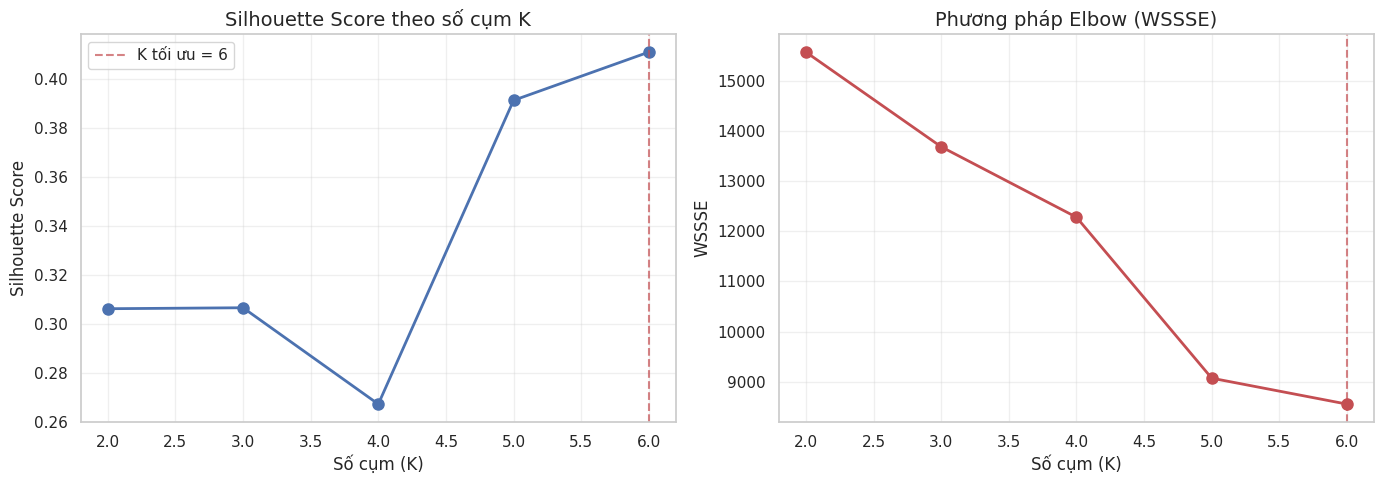

In [10]:
# ==========================================
# 7. TỐI ƯU TÌM K (CHỈ DÙNG MẪU)
# ==========================================
print("\n=== TÌM K TỐI ƯU (CHỈ DÙNG 10-20% DỮ LIỆU) ===")

# Lấy mẫu ngẫu nhiên để tìm K nhanh hơn
total_users = scaled_data.count()
sample_fraction = min(0.1, 5000.0 / total_users)  # Tối đa 5000 mẫu
print(f"Tổng số user: {total_users}, lấy mẫu {sample_fraction*100:.1f}%")

sampled_data = scaled_data.sample(fraction=sample_fraction, seed=42)
sampled_data.cache()
sample_count = sampled_data.count()
print(f"Số lượng mẫu sử dụng: {sample_count}")

# Tìm K tối ưu với số lượng K ít hơn
k_values = [2, 3, 4, 5, 6]
silhouette_scores = []
wssse_scores = []

for k in k_values:
    print(f"Đang thử nghiệm K = {k}...")
    kmeans = KMeans(
        featuresCol="features", 
        k=k, 
        seed=42, 
        maxIter=10, 
        tol=1e-2  # Tăng tol để hội tụ nhanh hơn
    )
    model = kmeans.fit(sampled_data)
    predictions = model.transform(sampled_data)
    
    # Tính Silhouette Score
    evaluator = ClusteringEvaluator(
        featuresCol="features", 
        metricName="silhouette"
    )
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)
    
    # Tính WSSSE (Within Set Sum of Squared Errors)
    wssse = model.summary.trainingCost
    wssse_scores.append(wssse)
    
    print(f"  K = {k}: Silhouette = {silhouette:.4f}, WSSSE = {wssse:.2f}")

# Giải phóng bộ nhớ của sampled_data
sampled_data.unpersist()

# Chọn K tối ưu dựa trên Silhouette Score
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"\n=== K TỐI ƯU ĐƯỢC CHỌN: K = {optimal_k} ===")
print(f"Silhouette Score cao nhất: {max(silhouette_scores):.4f}")

# Vẽ biểu đồ để trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Silhouette
axes[0].plot(k_values, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Số cụm (K)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score theo số cụm K', fontsize=14)
axes[0].axvline(x=optimal_k, color='r', linestyle='--', alpha=0.7, 
                label=f'K tối ưu = {optimal_k}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Biểu đồ WSSSE (Elbow)
axes[1].plot(k_values, wssse_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Số cụm (K)', fontsize=12)
axes[1].set_ylabel('WSSSE', fontsize=12)
axes[1].set_title('Phương pháp Elbow (WSSSE)', fontsize=14)
axes[1].axvline(x=optimal_k, color='r', linestyle='--', alpha=0.7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# 8. CHẠY K-MEANS CUỐI CÙNG
# ==========================================
print(f"\n=== CHẠY K-MEANS VỚI K = {optimal_k} TRÊN TOÀN BỘ DỮ LIỆU ===")

kmeans_final = KMeans(
    featuresCol="features", 
    predictionCol="cluster", 
    k=optimal_k, 
    seed=42, 
    maxIter=20
)

model_final = kmeans_final.fit(scaled_data)
predictions = model_final.transform(scaled_data)

# Đánh giá cuối cùng
final_evaluator = ClusteringEvaluator(
    featuresCol="features", 
    predictionCol="cluster", 
    metricName="silhouette"
)
final_silhouette = final_evaluator.evaluate(predictions)
print(f"Silhouette Score cuối cùng trên toàn bộ dữ liệu: {final_silhouette:.4f}")


=== CHẠY K-MEANS VỚI K = 6 TRÊN TOÀN BỘ DỮ LIỆU ===


Silhouette Score cuối cùng trên toàn bộ dữ liệu: 0.4041


In [12]:
# ==========================================
# 9. GÁN NHÃN CLUSTER (CẢI TIẾN)
# ==========================================
print("\n=== PHÂN TÍCH VÀ GÁN NHÃN CLUSTER ===")

# Phân tích đặc điểm từng cluster với đầy đủ features
cluster_analysis = predictions.groupBy("cluster").agg(
    F.count("user_id").alias("user_count"),
    F.avg("total_listens").alias("avg_total_listens"),
    F.avg("night_ratio").alias("avg_night_ratio"),
    F.avg("morning_ratio").alias("avg_morning_ratio"),
    F.avg("afternoon_ratio").alias("avg_afternoon_ratio"),
    F.avg("evening_ratio").alias("avg_evening_ratio"),
    F.avg("diversity_score").alias("avg_diversity"),
    F.avg("active_days").alias("avg_active_days"),
    F.avg("avg_listen_hour").alias("avg_listen_hour"),
    F.avg("hour_consistency").alias("avg_consistency"),
    F.avg("activity_intensity").alias("avg_intensity")
).orderBy("cluster")

cluster_profile = cluster_analysis.toPandas()
print("\nĐặc điểm chi tiết các cụm:")
print(cluster_profile.to_string())

# Gán nhãn thông minh dựa trên đặc điểm của từng cluster
def assign_intelligent_labels(row, cluster_profile):
    """Gán nhãn dựa trên phân tích đa chiều"""
    # Xác định thời gian hoạt động chính
    time_prefs = {
        'Night Owl': row['avg_night_ratio'],
        'Early Bird': row['avg_morning_ratio'],
        'Afternoon': row['avg_afternoon_ratio'],
        'Evening': row['avg_evening_ratio']
    }
    primary_time = max(time_prefs, key=time_prefs.get)
    
    # Xác định mức độ tương tác
    if row['avg_total_listens'] > cluster_profile['avg_total_listens'].quantile(0.75):
        engagement = "Super"
    elif row['avg_total_listens'] > cluster_profile['avg_total_listens'].median():
        engagement = "Active"
    else:
        engagement = "Light"
    
    # Xác định mức độ đa dạng
    if row['avg_diversity'] > cluster_profile['avg_diversity'].quantile(0.75):
        diversity = "Explorer"
    elif row['avg_diversity'] > cluster_profile['avg_diversity'].median():
        diversity = "Moderate"
    else:
        diversity = "Loyalist"
    
    # Kết hợp để tạo nhãn
    if primary_time == "Night Owl":
        if engagement == "Super":
            return f"Super Night Owl"
        elif engagement == "Active":
            return f"Active Night Owl"
        else:
            return f"Night Owl - {diversity}"
    elif primary_time == "Early Bird":
        if engagement == "Super":
            return f"Super Early Bird"
        elif engagement == "Active":
            return f"Active Early Bird"
        else:
            return f"Early Bird - {diversity}"
    else:
        if engagement == "Super":
            return f"Super {primary_time} {diversity}"
        elif engagement == "Active":
            return f"Active {primary_time} {diversity}"
        else:
            return f"{primary_time} {diversity}"

# Gán nhãn cho từng cluster
cluster_profile['user_type'] = cluster_profile.apply(
    lambda row: assign_intelligent_labels(row, cluster_profile), 
    axis=1
)
label_mapping = dict(zip(cluster_profile['cluster'], cluster_profile['user_type']))

print("\n=== GÁN NHÃN CHO CÁC CỤM ===")
for cluster, label in label_mapping.items():
    print(f"Cluster {cluster}: {label}")

# Thêm nhãn vào kết quả
from pyspark.sql.functions import create_map, lit
mapping_expr = create_map([lit(x) for pair in label_mapping.items() for x in pair])
final_results = predictions.withColumn("user_type", mapping_expr.getItem(F.col("cluster")))


=== PHÂN TÍCH VÀ GÁN NHÃN CLUSTER ===



Đặc điểm chi tiết các cụm:
   cluster  user_count  avg_total_listens  avg_night_ratio  avg_morning_ratio  avg_afternoon_ratio  avg_evening_ratio  avg_diversity  avg_active_days  avg_listen_hour  avg_consistency  avg_intensity
0        0       14145       1.050807e+03         0.076870           0.275485             0.426801           0.220844      40.610748        40.047437        14.197224         3.433733      18.681681
1        1       10482       2.228678e+03         0.396712           0.185688             0.217304           0.200296      26.852313        73.920721        12.038506         7.290090      26.115013
2        2        1613       1.017210e+04         0.241342           0.275732             0.296391           0.186535      13.383849        87.464972        12.344806         6.124590     124.080106
3        3           1       5.272810e+06         0.243929           0.329450             0.283098           0.143523       0.512023      2394.000000        11.825012         6

/usr/local/lib/python3.12/dist-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


In [13]:
# ==========================================
# 10. LƯU KẾT QUẢ
# ==========================================
print("\n=== LƯU KẾT QUẢ ===")

# Lưu kết quả với số partition nhỏ để tránh nhiều file nhỏ
output_path = "/kaggle/working/user_classification_optimized"
final_results.select(
    "user_id", "cluster", "user_type", 
    "total_listens", "night_ratio", "diversity_score",
    "active_days", "avg_listen_hour", "activity_intensity"
).coalesce(1).write.mode("overwrite").option("header", "true").csv(output_path)

print(f"Đã lưu kết quả vào {output_path}")


=== LƯU KẾT QUẢ ===
Đã lưu kết quả vào /kaggle/working/user_classification_optimized


In [14]:
# ==========================================
# 11. THỐNG KÊ KẾT QUẢ
# ==========================================
print("\n=== THỐNG KÊ KẾT QUẢ PHÂN LOẠI ===")
final_results.groupBy("user_type").agg(
    F.count("user_id").alias("số_lượng"),
    F.avg("total_listens").alias("lượt_nghe_TB"),
    F.avg("night_ratio").alias("tỷ_lệ_nghe_đêm_TB"),
    F.avg("diversity_score").alias("điểm_đa_dạng_TB"),
    F.avg("active_days").alias("ngày_hoạt_động_TB")
).orderBy(F.col("số_lượng").desc()).show(truncate=False)



=== THỐNG KÊ KẾT QUẢ PHÂN LOẠI ===


+-------------------------+--------+------------------+-------------------+------------------+------------------+
|user_type                |số_lượng|lượt_nghe_TB      |tỷ_lệ_nghe_đêm_TB  |điểm_đa_dạng_TB   |ngày_hoạt_động_TB |
+-------------------------+--------+------------------+-------------------+------------------+------------------+
|Afternoon Explorer       |14145   |1050.8068575468362|0.07686977517168092|40.61074805681274 |40.04743725698127 |
|Night Owl - Moderate     |10482   |2228.678496470139 |0.39671153360375755|26.852312941082012|73.92072123640527 |
|Night Owl - Explorer     |1734    |104.69031141868513|0.5745516322462264 |70.38096881716146 |6.428489042675894 |
|Active Afternoon Loyalist|1613    |10172.101673899566|0.24134208588893447|13.383849218633669|87.4649721016739  |
|Super Afternoon Loyalist |789     |133985.92902408112|0.23905325818996254|7.225341375264856 |2937.2636248415715|
|Super Early Bird         |1       |5272810.0         |0.2439285693965836 |0.51202300101


=== VẼ BIỂU ĐỒ PHÂN TÍCH ===


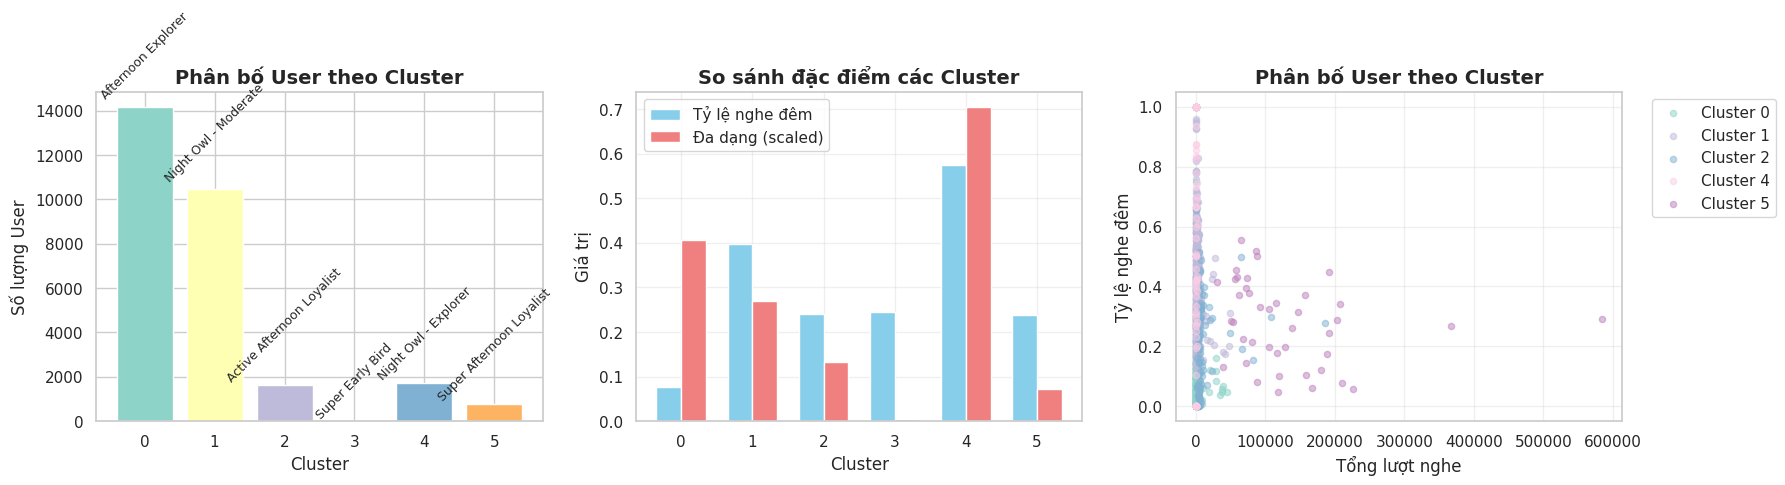

In [15]:
# ==========================================
# 12. VISUALIZATION NHANH
# ==========================================
print("\n=== VẼ BIỂU ĐỒ PHÂN TÍCH ===")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ 1: Phân bố số lượng user theo cluster
ax1 = axes[0]
bars = ax1.bar(cluster_profile['cluster'].astype(str), cluster_profile['user_count'], 
               color=plt.cm.Set3(range(len(cluster_profile))))
ax1.set_xlabel('Cluster', fontsize=12)
ax1.set_ylabel('Số lượng User', fontsize=12)
ax1.set_title('Phân bố User theo Cluster', fontsize=14, fontweight='bold')
for bar, label in zip(bars, cluster_profile['user_type']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.02,
             label, ha='center', va='bottom', fontsize=9, rotation=45)

# Biểu đồ 2: So sánh tỷ lệ nghe đêm và đa dạng
ax2 = axes[1]
x = np.arange(len(cluster_profile))
width = 0.35
ax2.bar(x - width/2, cluster_profile['avg_night_ratio'], width, label='Tỷ lệ nghe đêm', color='skyblue')
ax2.bar(x + width/2, cluster_profile['avg_diversity']/100, width, label='Đa dạng (scaled)', color='lightcoral')
ax2.set_xlabel('Cluster', fontsize=12)
ax2.set_ylabel('Giá trị', fontsize=12)
ax2.set_title('So sánh đặc điểm các Cluster', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(cluster_profile['cluster'].astype(str))
ax2.legend()
ax2.grid(True, alpha=0.3)

# Biểu đồ 3: Lấy mẫu 5% dữ liệu để vẽ scatter
ax3 = axes[2]
sample_viz = final_results.select("total_listens", "night_ratio", "cluster", "user_type") \
                          .sample(fraction=0.05, seed=42) \
                          .toPandas()

colors_viz = plt.cm.Set3(np.linspace(0, 1, optimal_k))
for idx, cluster in enumerate(sorted(sample_viz['cluster'].unique())):
    subset = sample_viz[sample_viz['cluster'] == cluster]
    ax3.scatter(subset['total_listens'], subset['night_ratio'], 
                c=[colors_viz[idx]], label=f"Cluster {cluster}", alpha=0.5, s=20)
ax3.set_xlabel('Tổng lượt nghe', fontsize=12)
ax3.set_ylabel('Tỷ lệ nghe đêm', fontsize=12)
ax3.set_title('Phân bố User theo Cluster', fontsize=14, fontweight='bold')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
# ==========================================
# 13. DỌN DẸP BỘ NHỚ
# ==========================================
print("\n=== DỌN DẸP BỘ NHỚ ===")

# Unpersist các DataFrame đã cache
df.unpersist()
df_processed.unpersist()
user_features_optimized.unpersist()
scaled_data.unpersist()

# Stop Spark session
spark.stop()
print("\n=== PHÂN TÍCH HOÀN TẤT ===")


=== DỌN DẸP BỘ NHỚ ===


26/03/21 10:59:47 WARN BlockManager: Block rdd_41_2 could not be removed as it was not found on disk or in memory
26/03/21 10:59:47 WARN BlockManager: Block rdd_41_59 could not be removed as it was not found on disk or in memory
26/03/21 10:59:47 WARN BlockManager: Block rdd_41_23 could not be removed as it was not found on disk or in memory
26/03/21 10:59:47 WARN BlockManager: Block rdd_41_89 could not be removed as it was not found on disk or in memory
26/03/21 10:59:47 WARN BlockManager: Block rdd_41_15 could not be removed as it was not found on disk or in memory
26/03/21 10:59:47 WARN BlockManager: Block rdd_41_60 could not be removed as it was not found on disk or in memory
26/03/21 10:59:47 WARN BlockManager: Block rdd_41_6 could not be removed as it was not found on disk or in memory
26/03/21 10:59:47 WARN BlockManager: Block rdd_41_81 could not be removed as it was not found on disk or in memory
26/03/21 10:59:47 WARN BlockManager: Block rdd_41_3 could not be removed as it was


=== PHÂN TÍCH HOÀN TẤT ===
